In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
import pandas as pd
import seaborn as sns
import sqlite3
import sqlalchemy
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column, Session
from datetime import datetime

sns.set_theme(style="darkgrid")

combined_db = Path("../agg_sensors_250915_to_260726.sqlite")


class Base(DeclarativeBase):
    pass


class Reading(Base):
    __tablename__ = "readings"
    date: Mapped[datetime] = mapped_column(primary_key=True)
    temperature: Mapped[float]
    pressure: Mapped[float]
    humidity: Mapped[float]
    gas_resistance: Mapped[float]
    iaq: Mapped[float]
    oxidising: Mapped[float]
    reducing: Mapped[float]
    nh3: Mapped[float]
    r: Mapped[int]
    g: Mapped[int]
    b: Mapped[int]
    c: Mapped[int]

In [ ]:
# files = ["../logs/sensors_240926_170130.csv"]
# frames = [pd.read_csv(str(f), on_bad_lines="skip", low_memory=False).dropna() for f in files]

frames = []
for f in sorted(Path("../logs").glob("sensors_2*.csv.gz")):
    try:
        print(f)
        df = pd.read_csv(str(f), on_bad_lines="skip", low_memory=False).dropna()
        if "iaq" in df.columns:
            del df["iaq"]

        frames.append(df)
    except Exception as e:
        print(e)

df = pd.concat(frames)
print(df.shape)
df["time"] = pd.to_datetime(df["time"], format="mixed", errors="coerce")
df.dropna(inplace=True)
df.set_index("time", inplace=True)
df = df.apply(pd.to_numeric, errors="coerce")
df.dropna(inplace=True)
df.sort_index(inplace=True)

print(df.shape)
display(df.iloc[[0, 1, -2, -1]])
df["temperature"].iloc[1:].plot()

In [ ]:
df_sel = df["2024-09-27":"2024-11-02"]["temperature"]

df_hmean = df_sel.groupby(pd.Grouper(freq="H")).mean().dropna(how="all")
df_hmax = df_sel.groupby(pd.Grouper(freq="H")).max().dropna(how="all")
df_hmin = df_sel.groupby(pd.Grouper(freq="H")).min().dropna(how="all")

plt.figure(figsize=(20, 8))
plt.xticks(rotation=90)
ax = sns.lineplot(df_hmean)
sns.lineplot(df_hmin, ax=ax, c="r", alpha=0.1)
sns.lineplot(df_hmax, ax=ax, c="r", alpha=0.1)
line = ax.get_lines()
plt.fill_between(line[0].get_xdata(), line[1].get_ydata(), line[2].get_ydata(), color="r", alpha=0.25)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
# ax.yaxis.set_major_locator(MultipleLocator(1))

In [ ]:
engine = sqlalchemy.create_engine("sqlite:///test.sqlite", echo=True)
Reading.metadata.create_all(engine)

with Session(engine) as session:
    r = Reading(
        date=datetime.now(),
        temperature=22,
        pressure=1000,
        humidity=60,
        gas_resistance=1e6,
        iaq=95,
        oxidising=1e7,
        reducing=2e6,
        nh3=3e7,
        r=100,
        g=100,
        b=100,
        c=100,
    )
    # r.temperature=r.temperature/10
    session.add(r)
    session.commit()

########################

engine = sqlalchemy.create_engine("sqlite:///test.sqlite", echo=False)
Reading.metadata.create_all(engine)
with Session(engine) as session:
    df = pd.read_sql(session.query(Reading).statement, session.bind)

print(df.dtypes)
df

In [ ]:
# engine = sqlalchemy.create_engine("sqlite:///../sensors_240926_170130.sqlite", echo=True)
# Reading.metadata.create_all(engine)
# readings=[]

# for item in df.iloc:
#     date=item.name.to_pydatetime()
#     readings.append(Reading(date=date,**item))

# with Session(engine) as session:
#     session.add_all(readings)
#     session.commit()

# with Session(engine) as session:
#     print(session.execute(sqlalchemy.select(Reading)).all())

In [ ]:
frames = []

for db in sorted(Path("..").glob("sensors_*.sqlite")):
    print(db)
    with sqlite3.connect(str(db)) as con:
        df = pd.read_sql_query("SELECT * from readings", con)
        df.date = pd.to_datetime(df.date, format="mixed", errors="coerce")
        df.c = pd.to_numeric(df.c, errors="coerce")
        df.nh3 = pd.to_numeric(df.nh3, errors="coerce")
        df.dropna(inplace=True)
        df.c = df.c.astype("int32")
        df = df[
            df.c.ge(0)
            & df.date.notna()
            & df.pressure.between(500, 2000)
            & df.temperature.between(-50, 50)
            & df.humidity.between(10, 90)
        ]

        df.set_index("date", inplace=True)
    frames.append(df)

display(df.dtypes)
display(df)

Get table info:

```
cur = con.cursor()
cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(db, cur.fetchall())
```

Sqlalchemy query:

```
engine = sqlalchemy.create_engine(f"sqlite:///{db}", echo=False)
with Session(engine) as session:
    df=pd.read_sql(session.query(Reading).statement,session.bind)
    df.set_index("date", inplace=True)
```

In [ ]:
if combined_db.exists():
    combined_db.unlink()

engine = sqlalchemy.create_engine(f"sqlite:///{combined_db}", echo=True)
Reading.metadata.create_all(engine)

with sqlite3.connect(combined_db) as con:
    for f in frames:
        f.to_sql("readings", con, if_exists="append")

Using Sqlalchemy, though types not enforced so little point:

```
readings=[]
for item in df.iloc:
    date=item.name.to_pydatetime()
    readings.append(Reading(date=date,**item))

with Session(engine) as session:
    session.add_all(readings)
    session.commit()

```

In [8]:
with sqlite3.connect(combined_db) as con:
    df = pd.read_sql_query("SELECT * from readings order by date desc limit 100000", con)
    df.date = pd.to_datetime(df.date, format="mixed", errors="coerce")
    df.set_index("date", inplace=True)
    df.sort_index(inplace=True)

print(df.shape, df.dtypes)
with pd.option_context("display.float_format", "{:.2f}".format):
    display(df.describe())
    display(df)

(100000, 12) temperature       float64
pressure          float64
humidity          float64
gas_resistance    float64
iaq               float64
oxidising         float64
reducing          float64
nh3               float64
r                   int64
g                   int64
b                   int64
c                   int64
dtype: object


,temperature,pressure,humidity,gas_resistance,iaq,oxidising,reducing,nh3,r,g,b,c
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,28.23,1015.20,37.51,1688480.28,84.43,127607.58,153817.43,87887.26,56.42,76.14,48.22,10.79
std,0.99,2.58,2.81,435854.19,12.81,5633.58,5362.20,4497.77,68.59,87.44,51.52,12.89
min,25.74,1011.63,31.31,989850.17,61.00,116680.72,144454.55,80744.19,0.00,0.00,0.00,0.00
25%,27.41,1013.33,36.07,1267326.73,71.71,124566.93,148021.35,83914.58,0.00,0.00,0.00,0.00
50%,28.32,1014.68,37.57,1791384.21,92.00,126000.00,156530.12,88317.18,34.00,53.00,39.00,7.00
75%,29.04,1017.21,39.45,2137787.06,96.76,130742.67,158317.76,90905.83,87.00,118.00,76.00,17.00
max,29.70,1020.42,42.46,2398828.70,99.96,143062.50,165351.35,99050.71,922.00,974.00,540.00,160.00


,temperature,pressure,humidity,gas_resistance,iaq,oxidising,reducing,nh3,r,g,b,c
date,,,,,,,,,,,,
2026-08-09 08:00:58.846816,25.74,1015.29,38.86,2022216.74,99.29,134623.44,159932.20,93102.73,145,188,109,28
2026-08-09 08:00:59.857504,25.74,1015.29,38.87,2028224.81,99.29,134623.44,160135.72,93199.74,141,182,106,28
2026-08-09 08:01:00.868383,25.74,1015.29,38.86,2017733.99,99.29,134623.44,160339.62,93102.73,137,175,103,26
2026-08-09 08:01:01.879083,25.74,1015.29,38.87,2026719.45,99.29,134623.44,160135.72,93102.73,126,167,98,25
2026-08-09 08:01:02.889726,25.75,1015.28,38.87,2025216.32,99.29,134782.03,160135.72,93199.74,119,158,94,23
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-10 12:05:24.577902,29.08,1020.40,39.57,1335507.01,75.41,118387.83,146579.51,80825.78,73,104,70,14
2026-08-10 12:05:25.588062,29.08,1020.41,39.57,1331599.48,75.26,118387.83,146938.05,80907.46,74,105,70,14
2026-08-10 12:05:26.598851,29.08,1020.40,39.60,1329007.14,75.18,118520.55,147117.80,80907.46,74,106,71,14


<Axes: xlabel='date'>

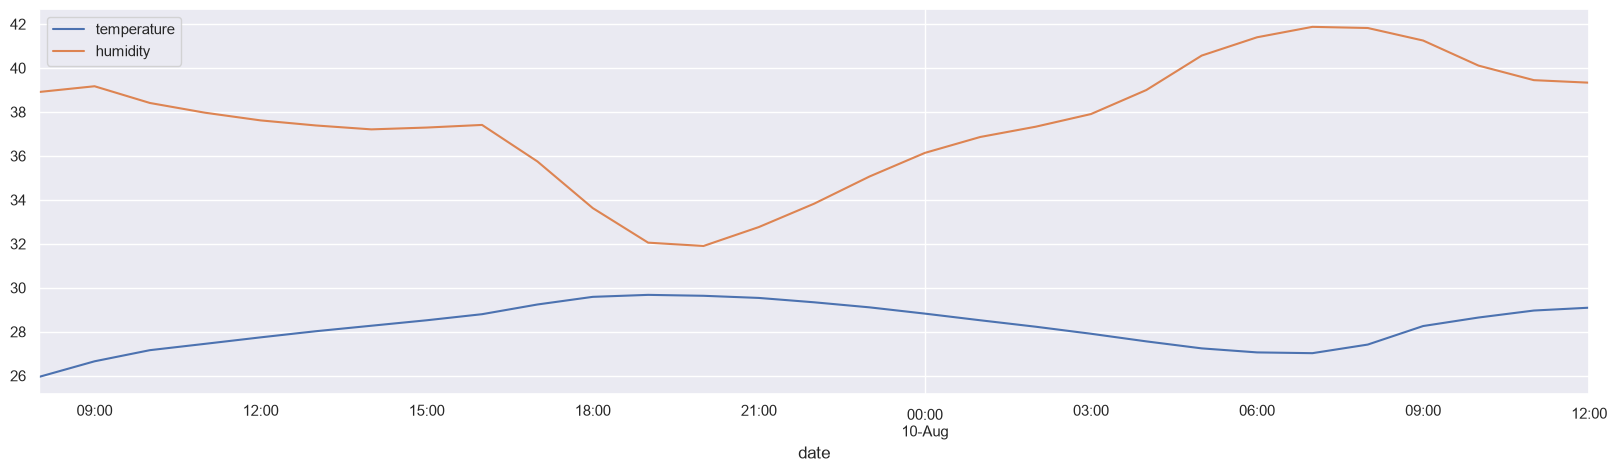

In [12]:
df_sel = df[["temperature", "humidity"]]
df_sel = df_sel.groupby(pd.Grouper(freq="60min")).mean().dropna(how="all")
# df_sel=(df_sel-df_sel.mean())/df_sel.std()

df_sel.plot(figsize=(20, 5))